Regression model summary!
                            OLS Regression Results                            
Dep. Variable:             Crude Rate   R-squared:                       0.262
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     9.710
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           1.64e-11
Time:                        06:00:09   Log-Likelihood:                -902.36
No. Observations:                 228   AIC:                             1823.
Df Residuals:                     219   BIC:                             1854.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

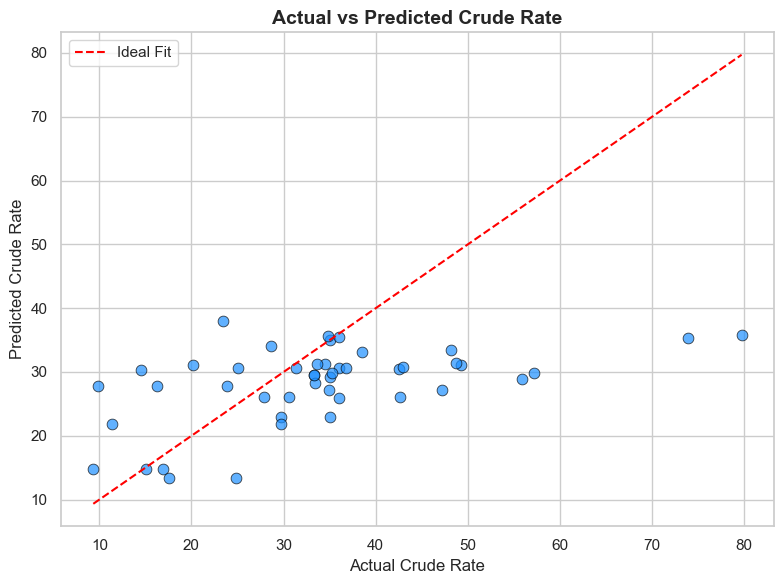

                            OLS Regression Results                            
Dep. Variable:             Crude Rate   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     57.53
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           1.71e-12
Time:                        06:00:09   Log-Likelihood:                -88.412
No. Observations:                 182   AIC:                             180.8
Df Residuals:                     180   BIC:                             187.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import glob
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns



def clean_crude_rate(df):
    df = df[~df['Crude Rate'].isin(['Unreliable', 'Suppressed'])].copy()
    df['Crude Rate'] = pd.to_numeric(df['Crude Rate'])
    return df

# Load file paths through
folder_path = "C:/Users/amyyy/OneDrive/Desktop/MATH_537/FINALPROJ/Data/Model/"
file_paths = glob.glob(folder_path + "*ModelData.csv")
all_years_df = pd.concat([pd.read_csv(file) for file in file_paths], ignore_index=True)

# Drop the nan values 
all_years_df = all_years_df.dropna(subset=[
    'Renter-occupied: 1.51 or more occupants per room',
    'County HIV Cases',
    'County HIV Rate',
    'Crude Rate',
    'Population',
    'Rate: Health Insurance',
    'Rate: No Health Insurance',
    'Percent Less Than HS',
    'Percent Some College',
    'Percent Unemployed',
    'Percent Owner-Occupied Crowded',
    'Median Household Income'
])

# Ensure the County Code variable is cleaned
all_years_df['County Code'] = all_years_df['County Code'].astype(str).str.zfill(5)

'''
PART ONE
We start by running ordinary linear regression in order 
to see which indicators are statistically significant.
We will keep any variable with a p-value less than 0.1
'''
filtered_df = clean_crude_rate(all_years_df)

X = filtered_df[
    [
        'Renter-occupied: 1.51 or more occupants per room',
        'County HIV Rate',
        'Rate: No Health Insurance',
        'Percent Less Than HS',
        'Percent Some College',
        'Percent Unemployed',
        'Percent Owner-Occupied Crowded',
        'Median Household Income'
    ]
]
y = filtered_df['Crude Rate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print("Regression model summary!")
print(model.summary())
X_const = add_constant(X)
vif_df = pd.DataFrame()
vif_df["Feature"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

''' 
Based on this summary, we find four indicators to be statistically significant
Renter-occupied: 1.51 or more occupants per room
Rate: No Health Insurance
Percent Some College
Percent Unemployed  
'''

'''
PART TWO
To calculate our 'vulnerability score', we will use PCA to project the data onto
a 1-D subspace
'''
pca_features = [
    'Renter-occupied: 1.51 or more occupants per room',
    'Rate: No Health Insurance',
    'Percent Some College',
    'Percent Unemployed',
]

vulnerability_dfs = []
pca_df = all_years_df.dropna(subset=pca_features).copy()
# Since Percent Some ColLege had a negative coefficient in the original linear regression, we flip it in PCA
pca_df['Percent Some College'] = -1*pca_df['Percent Some College']
pca_df['Renter-occupied: 1.51 or more occupants per room'] = -1*pca_df['Renter-occupied: 1.51 or more occupants per room']

# Since some values are very large, we standardize
# This makes every columns have a mean of 0 and a standard deviation of 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df[pca_features])

'''
How is the index calculated? 
We project the data onto the optimal 1-D subspace. 
We interpret the vulnerability index as the coordinate on this subspace.
Vulnerability Score = X /dot v 
where X is the column vector for a county and v is the principal component vector
We chose a 1-D subspace for ease of calculation/interpretation
'''
pca = PCA(n_components=1)
vulnerability_index = pca.fit_transform(X_scaled)
pca_df['Vulnerability Index'] = vulnerability_index
# vulnerability_index = (-1)*vulnerability_index
pca_df['Vulnerability Score (0-100)'] = (
        (vulnerability_index - vulnerability_index.min()) /
        (vulnerability_index.max() - vulnerability_index.min())
    ) * 100

all_years_df = all_years_df.merge(pca_df[['County Code', 'Year', 'Vulnerability Index', 'Vulnerability Score (0-100)']],
    on=['County Code', 'Year'],
    how='left'
)

'''
How to interpret this?
Features with high absolute value contribute more to vulnerability score
The sign of the loading indicates positive or negative influence
'''
print("Loadings")
print(pd.DataFrame({
    'Feature': pca_features,
    'Loading': pca.components_[0]
}).sort_values(by='Loading', key=abs, ascending=False))

filtered_df = clean_crude_rate(all_years_df)
''' 
PART THREE
We now verify to see how well the vulnerability index predicts opioid mortality
'''
X = filtered_df[['Vulnerability Score (0-100)']]
X = sm.add_constant(X)
y = filtered_df['Crude Rate']

model = sm.OLS(y, X).fit()
model_summary = model.summary()

model_summary.tables

X = filtered_df[['Vulnerability Score (0-100)']]
y = filtered_df['Crude Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

model = sm.OLS(y_train, X_train).fit()

y_pred = model.predict(X_test)

'''
Here we plot the differences in actual versus predicted crude rate
Note: this section of the code was originally written by the authors, but
was edited by ChatGPT for improved style
'''
# Set Seaborn style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, s=60, color="dodgerblue", edgecolor="black", alpha=0.7)

# Add a 45-degree reference line
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Fit")

# Labels and title
plt.xlabel("Actual Crude Rate", fontsize=12)
plt.ylabel("Predicted Crude Rate", fontsize=12)
plt.title("Actual vs Predicted Crude Rate", fontsize=14, weight='bold')

# Legend and layout
plt.legend()
plt.tight_layout()
plt.show()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(model.summary())
print(f"\nTest MSE: {mse:.2f}")
print(f"Test RMSE: {rmse:.2f}")